In [22]:
import pandas as pd 
import numpy as np

healthy_expr = pd.read_csv("../data/interim/healthy_expr.csv").set_index("Gene Symbol")
gbm_expr = pd.read_csv("../data/interim/gbm_expr.csv").set_index("Gene Symbol")

gbm_expr

,GSM97794,GSM97796,GSM97797,GSM97798,GSM97801,GSM97806,GSM97808,GSM97813,GSM97814,GSM97818,...,GSM97955,GSM97959,GSM97961,GSM97963,GSM97965,GSM97966,GSM97967,GSM97968,GSM97969,GSM97971
Gene Symbol,,,,,,,,,,,,,,,,,,,,,
A1BG,7.608809,6.244126,7.611025,6.882643,7.483816,6.850499,6.984134,6.947199,7.947199,7.464342,...,8.108524,6.008989,7.869748,7.584211,6.509379,7.635899,6.910493,7.577429,7.564531,7.900263
A1BG-AS1,4.672425,5.845490,4.738768,4.632268,5.083213,4.145677,4.193772,4.292782,4.963474,4.802193,...,4.972693,7.217231,4.035624,4.035624,3.906891,3.963474,5.149747,6.381975,4.263034,4.314697
A1CF,8.189330,8.083745,8.366322,8.432124,7.994353,8.586089,7.840463,8.192293,8.155324,7.932510,...,7.627169,8.074677,7.985842,7.427103,8.146187,8.222070,8.498650,8.248876,9.005344,7.707359
A2M,13.292221,14.357201,13.977468,12.993876,13.683905,13.235446,12.849444,13.948960,12.636443,13.955023,...,13.244721,13.356961,12.990547,13.740350,14.289515,14.151310,12.344573,11.931698,13.955468,13.491164
A2M-AS1,7.787903,7.351381,8.294161,7.416164,7.662490,7.605109,7.139551,8.696620,6.920055,7.539934,...,7.216261,7.426265,7.188836,7.054197,6.937815,7.180904,7.936638,7.761551,8.233140,8.799605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hADV36S1,6.922436,6.451211,5.318317,7.207502,5.857981,6.339850,6.361066,6.958843,6.821455,6.261155,...,6.921246,6.072535,4.459432,6.169925,6.298292,6.274262,5.449561,6.542258,6.339850,7.811856
hsa-let-7a-3,8.661422,8.159871,8.466382,9.072267,8.842665,9.280307,9.325305,8.343408,8.807677,8.623881,...,8.896332,8.483413,8.567956,9.083745,8.174926,9.198936,7.924219,8.320124,8.745506,9.566625
hsa-let-7b,8.661422,8.159871,8.466382,9.072267,8.842665,9.280307,9.325305,8.343408,8.807677,8.623881,...,8.896332,8.483413,8.567956,9.083745,8.174926,9.198936,7.924219,8.320124,8.745506,9.566625


# PCA 

In [23]:
expr = pd.concat([healthy_expr, gbm_expr], axis=1)

labels = (
    ["Healthy"] * healthy_expr.shape[1] +
    ["GBM"] * gbm_expr.shape[1]
)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

X = expr.T

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pcs,
    columns=["PC1", "PC2"]
)

pca_df["Group"] = labels

# Plot PCA

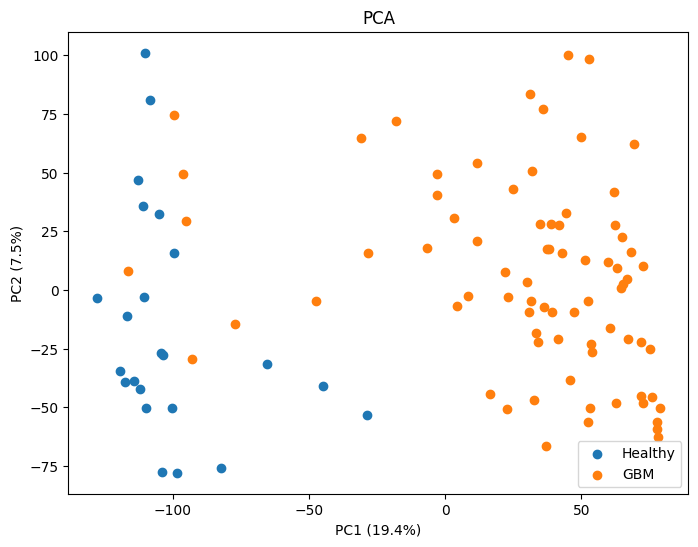

In [24]:
plt.figure(figsize=(8,6))

for group in ["Healthy", "GBM"]:
    mask = pca_df["Group"] == group
    plt.scatter(
        pca_df.loc[mask, "PC1"],
        pca_df.loc[mask, "PC2"],
        label=group
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)
plt.legend()
plt.title("PCA")
plt.show()

# Differential analysis


In [25]:
import numpy as np
from scipy.stats import ttest_ind

results = []

for gene in expr.index:

    healthy = healthy_expr.loc[gene]
    gbm = gbm_expr.loc[gene]

    log2fc = (
        gbm.mean() -
        healthy.mean()
    )

    pval = ttest_ind(
        gbm,
        healthy,
        equal_var=False
    ).pvalue

    results.append(
        [gene, log2fc, pval]
    )

de = pd.DataFrame(
    results,
    columns=["Gene", "log2FC", "pvalue"]
)

from statsmodels.stats.multitest import multipletests

de["FDR"] = multipletests(
    de["pvalue"],
    method="fdr_bh"
)[1]

de["adjustedpvalue"] = -np.log10(de["FDR"])

In [26]:
de

,Gene,log2FC,pvalue,FDR,adjustedpvalue
0,A1BG,-0.051346,7.039758e-01,7.649690e-01,0.116356
1,A1BG-AS1,-0.672637,1.985447e-03,4.269226e-03,2.369651
2,A1CF,-0.108210,2.963214e-01,3.778621e-01,0.422667
3,A2M,0.895503,2.751120e-10,1.613700e-09,8.792177
4,A2M-AS1,-0.090777,2.875495e-01,3.685866e-01,0.433461
...,...,...,...,...,...
24437,hADV36S1,0.664209,1.269336e-03,2.819184e-03,2.549877
24438,hsa-let-7a-3,0.576475,6.739545e-08,2.813458e-07,6.550760
24439,hsa-let-7b,0.576475,6.739545e-08,2.813458e-07,6.550760
24440,hsa-mir-4763,0.576475,6.739545e-08,2.813458e-07,6.550760


In [27]:
de = de.set_index("Gene")
de.to_csv("../data/processed/de_transcriptome.csv")
de

,log2FC,pvalue,FDR,adjustedpvalue
Gene,,,,
A1BG,-0.051346,7.039758e-01,7.649690e-01,0.116356
A1BG-AS1,-0.672637,1.985447e-03,4.269226e-03,2.369651
A1CF,-0.108210,2.963214e-01,3.778621e-01,0.422667
A2M,0.895503,2.751120e-10,1.613700e-09,8.792177
A2M-AS1,-0.090777,2.875495e-01,3.685866e-01,0.433461
...,...,...,...,...
hADV36S1,0.664209,1.269336e-03,2.819184e-03,2.549877
hsa-let-7a-3,0.576475,6.739545e-08,2.813458e-07,6.550760
hsa-let-7b,0.576475,6.739545e-08,2.813458e-07,6.550760


# Plot volcano

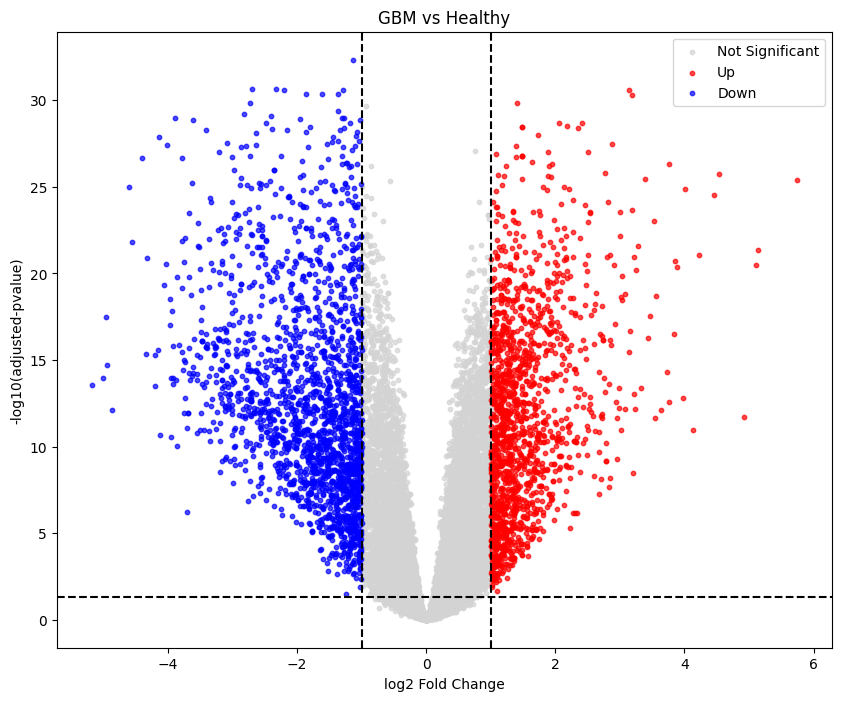

In [28]:
import numpy as np
import matplotlib.pyplot as plt



de["category"] = "Not Significant"
de.loc[
    (de["FDR"] < 0.05) & (de["log2FC"] > 1),
    "category"
] = "Up"

de.loc[
    (de["FDR"] < 0.05) & (de["log2FC"] < -1),
    "category"
] = "Down"

colors = {
    "Up": "red",
    "Down": "blue",
    "Not Significant": "lightgray"
}

plt.figure(figsize=(10, 8))

for cat in ["Not Significant", "Up", "Down"]:
    subset = de[de["category"] == cat]

    plt.scatter(
        subset["log2FC"],
        subset["adjustedpvalue"],
        c=colors[cat],
        label=cat,
        s=10,
        alpha=0.7
    )

plt.axvline(1, linestyle="--", color="black")
plt.axvline(-1, linestyle="--", color="black")
plt.axhline(-np.log10(0.05), linestyle="--", color="black")

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(adjusted-pvalue)")
plt.title("GBM vs Healthy")
plt.legend()
plt.show()